# 4. Diskretni signali in sistemi v frekvenčnem prostoru

Ta interaktivni zvezek obravnava frekvenčno predstavitev signalov in analizo Linearnih Časovno Invariantnih (LČI) sistemov. Temelji na spoznanju, da se vsi zvezni periodični signali lahko predstavijo z vsoto pravilno izbranih sinusnih signalov.

## 4.1 Signal v časovni in frekvenčni domeni
Pri analizi signalov pogosto trčimo ob problem, da so signali manjših amplitud v časovni domeni skriti ali slabo vidni, medtem ko postanejo v frekvenčni domeni (spektru) zelo jasno prepoznavni. 

V spodnjem primeru bomo ustvarili sestavljen zvočni signal (nizek močen ton + visok šibek ton + šum) in ga analizirali v obeh domenah.

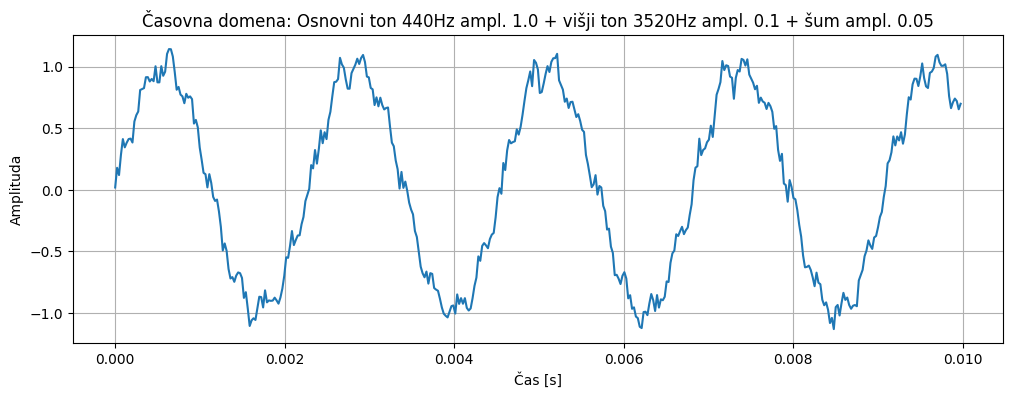

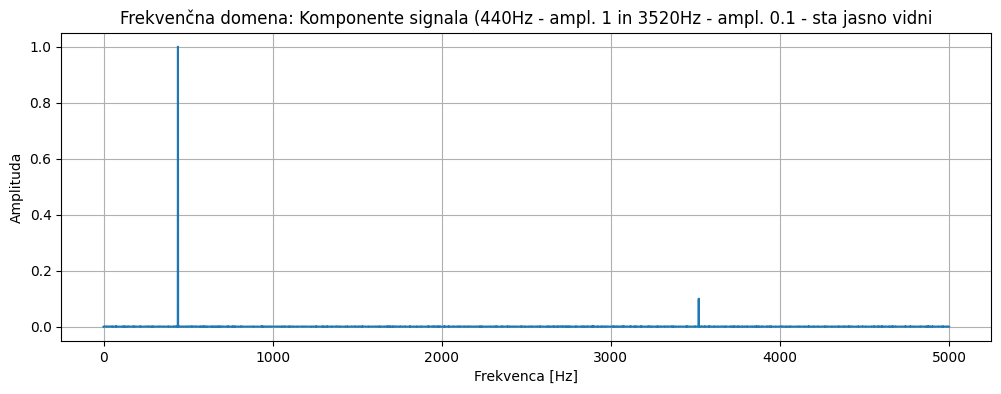

Poslušaj čisti ton 440Hz (brez šuma in visokega tona):


Poslušaj sestavljeni signal (z vključenim šumom in visokim tonom):


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import signal
from IPython.display import Audio

# 1. Parametri signala
fs = 44100  # Frekvenca vzorčenja v Hz (CD kvaliteta)
t = np.linspace(0, 1.0, fs, endpoint=False)  # Časovni vektor (1 sekunda)

# 2. Sestavljanje signala
f1, A1 = 440.0, 1.0    # Osnovni ton (A4), močna amplituda
f2, A2 = 3520.0, 0.1   # Višji harmonski ton, majhna amplituda
x = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)
x_noise = x + np.random.normal(0, 0.05, len(t)) # Dodamo rahel šum

# 3. Časovna domena
plt.figure(figsize=(12, 4))
samples = int(fs * 0.01) # Prikaz prvih 10 milisekund
plt.plot(t[:samples], x_noise[:samples])
plt.title('Časovna domena: Osnovni ton 440Hz ampl. 1.0 + višji ton 3520Hz ampl. 0.1 + šum ampl. 0.05')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

# 4. Frekvenčna domena (Amplitudni spekter)
N = len(x_noise)
yf = fft(x_noise)
xf = fftfreq(N, 1/fs)

plt.figure(figsize=(12, 4))
mask = (xf >= 0) & (xf <= 5000) # Gledamo samo do 5 kHz
plt.plot(xf[mask], 2.0/N * np.abs(yf[mask]))
plt.title('Frekvenčna domena: Komponente signala (440Hz - ampl. 1 in 3520Hz - ampl. 0.1 - sta jasno vidni')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

# 5. Poslušanje osnovnga tona 440Hz
print("Poslušaj čisti ton 440Hz (brez šuma in visokega tona):")
display(Audio(A1 * np.sin(2 * np.pi * f1 * t), rate=fs))

# 6. Poslušanje sestavljenega signala
print("Poslušaj sestavljeni signal (z vključenim šumom in visokim tonom):")
display(Audio(x_noise, rate=fs))

## 4.3 Frekvenčni odziv LČI sistema
Frekvenčni odziv sistema opredeljuje kompleksna funkcija $H(e^{j\omega})$, ki nam pove, kaj se zgodi z vsako posamezno frekvenčno komponento pri prehodu skozi sistem. 
Delimo ga na:
* **Amplitudni odziv** ($|H(e^{j\omega})|$): določa spremembo amplitude lastne funkcije.
* **Fazni odziv** ($\angle H(e^{j\omega})$): določa spremembo faze oz. zakasnitev komponente.

Ustvarimo preprost LČI sistem (nizkoprepustni drseči povprečevalnik - Moving Average filter) in vizualizirajmo njegov odziv.

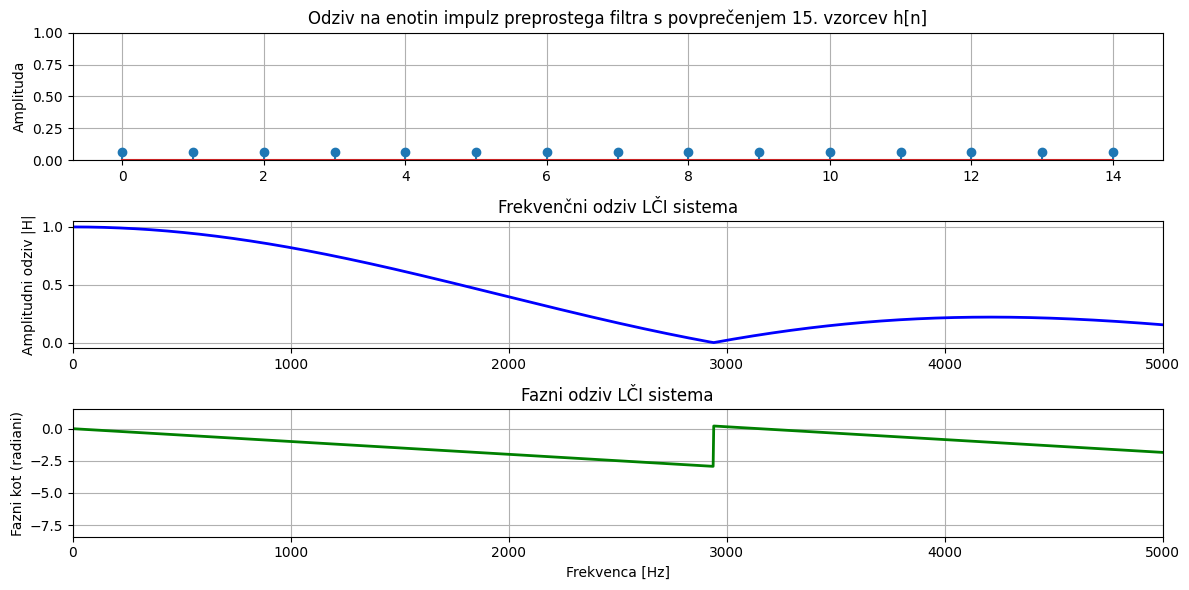

In [2]:
# Definiramo koeficiente za FIR nizkoprepustni filter
N_filter = 15 # Red filtra
h = np.ones(N_filter) / N_filter # Impulzni odziv sistema

# Izračun frekvenčnega odziva sistema H(e^jw)
w, H = signal.freqz(h, worN=8000)
frekvence_Hz = (w / np.pi) * (fs / 2)

plt.figure(figsize=(12, 6))

#Odziv na enotin impulz
#axs[0].stem(n, delta)
#axs[0].set_title('Enotin impulz δ[n]')

plt.subplot(3, 1, 1)
n = np.arange(0, N_filter)
plt.stem(n, h)
plt.title('Odziv na enotin impulz preprostega filtra s povprečenjem 15. vzorcev h[n]')
plt.ylabel('Amplituda')
plt.ylim(0, 1)
plt.grid(True)

# Amplitudni odziv
plt.subplot(3, 1, 2)
plt.plot(frekvence_Hz, np.abs(H), 'b', linewidth=2)
plt.title('Frekvenčni odziv LČI sistema')
plt.ylabel('Amplitudni odziv |H|')
plt.grid(True)
plt.xlim(0, 5000)

# Fazni odziv
plt.subplot(3, 1, 3)
angles = np.unwrap(np.angle(H))
plt.plot(frekvence_Hz, angles, 'g', linewidth=2)
plt.title('Fazni odziv LČI sistema')
plt.ylabel('Fazni kot (radiani)')
plt.xlabel('Frekvenca [Hz]')
plt.grid(True)
plt.xlim(0, 5000)

plt.tight_layout()
plt.show()

## Vpliv sistema na sestavljen signal
Vpliv sistema na sestavljeni signal je preprosto vsota odzivov na njegove posamezne komponente. Zgornji nizkoprepustni filter bomo sedaj uporabili na našem začetnem zvočnem signalu. Filter bo utišal visoke frekvence (šum in ton 3520 Hz), faza pa bo vplivala na zakasnitev preostalega signala v času.

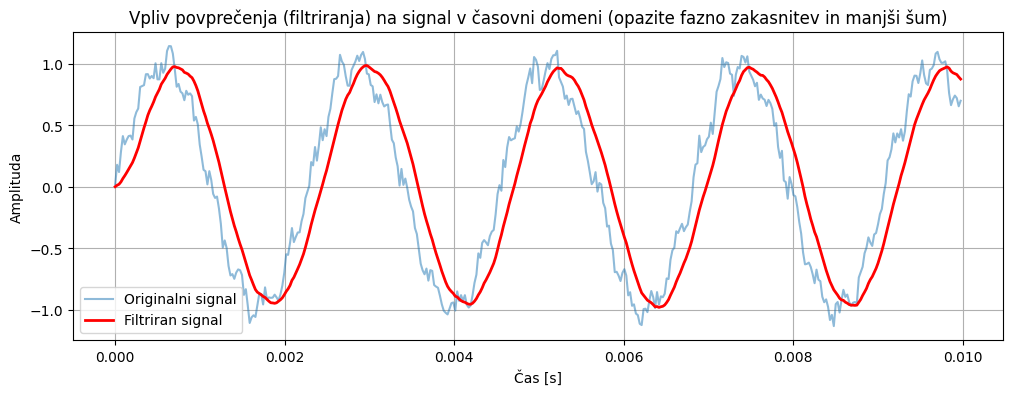

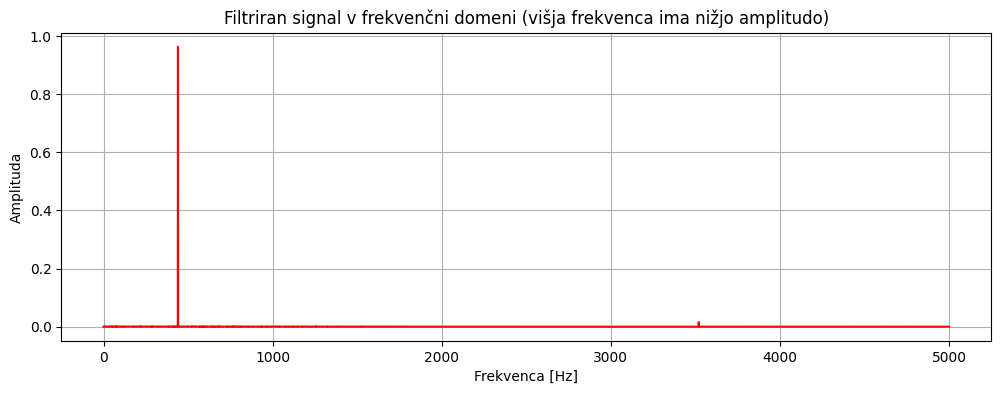

Poslušaj filtrirani signal (zveneti bi moral bolj čisto, z manj šuma in visokega tona):


In [3]:
# Uporaba filtra na signalu (konvolucija v časovni domeni)
y = signal.lfilter(h, 1.0, x_noise)

# Prikaz v časovni domeni (Zakasnitev in glajenje)
plt.figure(figsize=(12, 4))
plt.plot(t[:samples], x_noise[:samples], label='Originalni signal', alpha=0.5)
plt.plot(t[:samples], y[:samples], label='Filtriran signal', linewidth=2, color='red')
plt.title('Vpliv povprečenja (filtriranja) na signal v časovni domeni (opazite fazno zakasnitev in manjši šum)')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.legend()
plt.grid(True)
plt.show()

# Prikaz v frekvenčni domeni
yf_filtered = fft(y)
plt.figure(figsize=(12, 4))
plt.plot(xf[mask], 2.0/N * np.abs(yf_filtered[mask]), color='red')
plt.title('Filtriran signal v frekvenčni domeni (višja frekvenca ima nižjo amplitudo)')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

# Poslušanje filtriranega signala
print("Poslušaj filtrirani signal (zveneti bi moral bolj čisto, z manj šuma in visokega tona):")
display(Audio(y, rate=fs))

## Zveza med FT in Z-transformacijo
Za celovito razumevanje sistema je ključno poznavanje Z-transformacije. Fourierova transformacija je pravzaprav le poseben primer Z-transformacije, ki je ovrednotena izključno na enotski krožnici v Z-ravnini, torej pri $|z|=1$. Spodnji graf prikazuje položaj polov in ničel našega filtra.

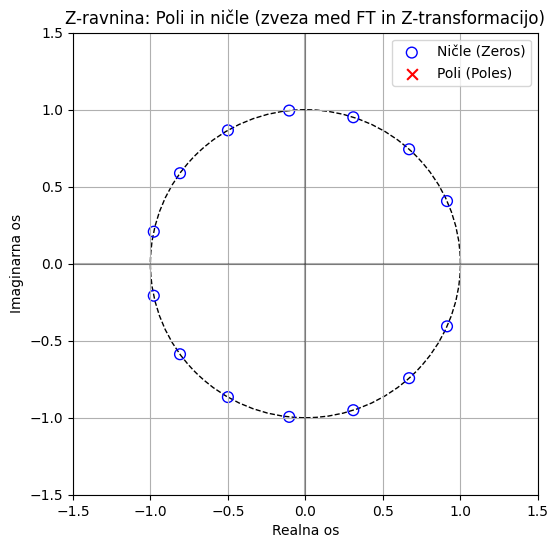

In [4]:
# Izračun polov in ničel prenosne funkcije H(z)
z, p, k = signal.tf2zpk(h, [1.0])

plt.figure(figsize=(6, 6))
# Risanje enotske krožnice
unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
plt.gca().add_patch(unit_circle)

# Risanje ničel (zeros) in polov (poles)
plt.scatter(np.real(z), np.imag(z), s=60, marker='o', facecolors='none', edgecolors='b', label='Ničle (Zeros)')
plt.scatter(np.real(p), np.imag(p), s=60, marker='x', color='r', label='Poli (Poles)')

plt.title('Z-ravnina: Poli in ničle (zveza med FT in Z-transformacijo)')
plt.xlabel('Realna os')
plt.ylabel('Imaginarna os')
plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=0, color='k', alpha=0.3)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## 4.4 Praktični primer: Vpliv amplitudnega odziva in grupne zakasnitve

Ta primer poustvarja klasičen problem iz predavanj: Kaj se zgodi, če skozi sistem pošljemo tri časovno ločene signale različnih frekvenc?

Opazovali bomo dva pojava:
1. **Vpliv amplitudnega odziva:** Eden od signalov bo popolnoma izginil (filtriranje).
2. **Vpliv grupne zakasnitve (Group Delay):** Sistem bo nizke frekvence zadržal precej dlje kot srednje. To bo povzročilo, da bo časovno kasnejši signal na izhodu **prehitel** prejšnjega!

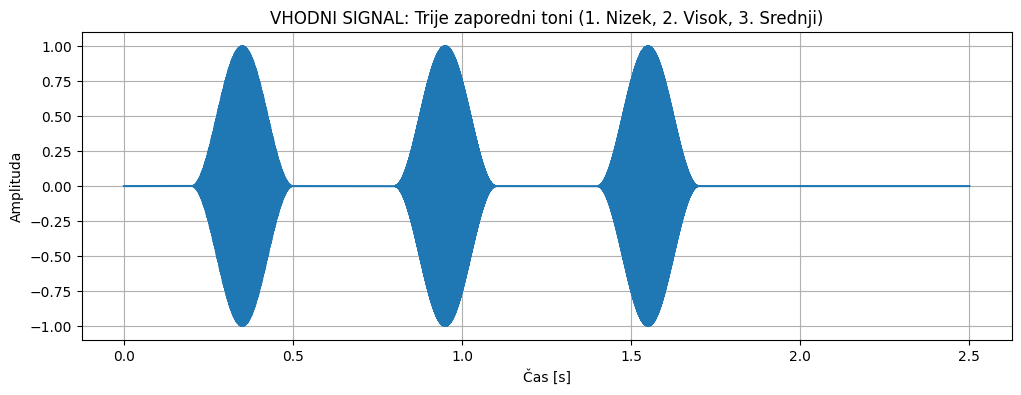

Poslušaj vhodni signal (Slišiš zaporedje: Nizek -> Visok -> Srednji):


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio

fs = 44100
t_in = np.linspace(0, 2.5, int(fs * 2.5), endpoint=False)

def make_burst(f, start_time, duration):
    """Ustvari kratek signal (burst) določene frekvence z zglajenimi robovi, da preprečimo pokanje."""
    burst = np.zeros_like(t_in)
    idx_start = int(start_time * fs)
    idx_end = int((start_time + duration) * fs)
    window = np.hanning(idx_end - idx_start) # Glajenje robov
    burst[idx_start:idx_end] = np.sin(2 * np.pi * f * t_in[idx_start:idx_end]) * window
    return burst

# 1. Generiranje treh zaporednih signalov
# Signal 1: Nizek ton, prvi po vrsti
x1 = make_burst(440, 0.2, 0.3)
# Signal 2: Visok ton, drugi po vrsti
x2 = make_burst(3500, 0.8, 0.3)
# Signal 3: Srednji ton, zadnji po vrsti
x3 = make_burst(1000, 1.4, 0.3)

x_input = x1 + x2 + x3

# Prikaz vhodnega signala
plt.figure(figsize=(12, 4))
plt.plot(t_in, x_input)
plt.title('VHODNI SIGNAL: Trije zaporedni toni (1. Nizek, 2. Visok, 3. Srednji)')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

print("Poslušaj vhodni signal (Slišiš zaporedje: Nizek -> Visok -> Srednji):")
display(Audio(x_input, rate=fs))


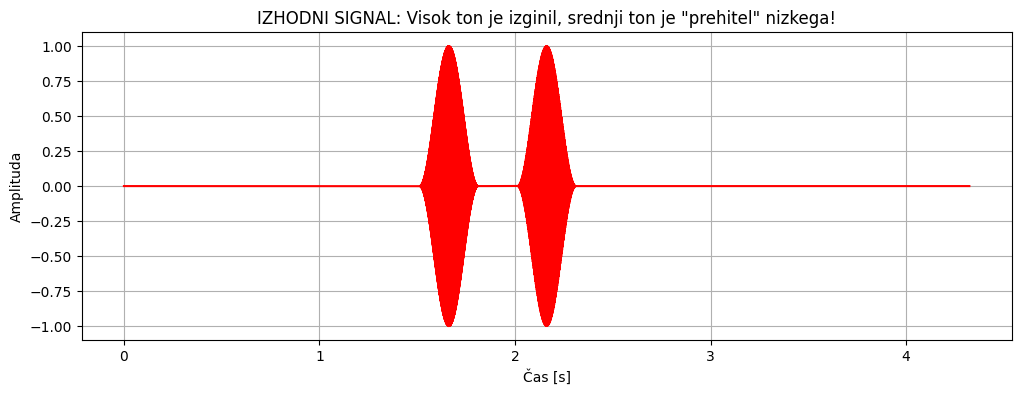

Poslušaj izhodni signal (Slišiš zaporedje: Srednji -> [tišina] -> Nizek):


In [6]:
# 2. Oblikovanje sistema (FIR filter)
# Da poustvarimo učinek s prosojnic, bomo zgradili LČI sistem, ki:
# - Prepušča 440 Hz z veliko zakasnitvijo (1.8 sekunde)
# - Prepušča 1000 Hz z majhno zakasnitvijo (0.1 sekunde)
# - Duši 3500 Hz (Amplitudni odziv = 0)

taps = 1025
h_low = signal.firwin(taps, [300, 600], fs=fs, pass_zero=False)
h_mid = signal.firwin(taps, [800, 1200], fs=fs, pass_zero=False)

delay_low_samples = int(1.8 * fs) # Grupna zakasnitev za nizek ton
delay_mid_samples = int(0.1 * fs) # Grupna zakasnitev za srednji ton

# Sestavimo impulzni odziv sistema (h)
h_length = max(delay_low_samples, delay_mid_samples) + taps
h = np.zeros(h_length)
h[delay_low_samples:delay_low_samples+taps] += h_low
h[delay_mid_samples:delay_mid_samples+taps] += h_mid

# 3. Prehod signala skozi sistem (Konvolucija)
y_output = signal.convolve(x_input, h, mode='full')
y_output = y_output / np.max(np.abs(y_output)) # Normalizacija glasnosti

# Časovni vektor za izhod (ker sistem signal zakasni, bo izhod daljši)
t_out = np.linspace(0, len(y_output) / fs, len(y_output), endpoint=False)

# Prikaz izhodnega signala
plt.figure(figsize=(12, 4))
plt.plot(t_out, y_output, color='red')
plt.title('IZHODNI SIGNAL: Visok ton je izginil, srednji ton je "prehitel" nizkega!')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

print("Poslušaj izhodni signal (Slišiš zaporedje: Srednji -> [tišina] -> Nizek):")
display(Audio(y_output, rate=fs))


## 4.5 Analiza preoblikovanja: Kaj se zgodi z vsako komponento?

Sistem je vhodni signal preoblikoval glede na amplitudni in fazni odziv. Poglejmo si podrobno usodo vsake izmed treh komponent:

1. **Nizek ton (440 Hz) - Prvi na vhodu:**
   - **Amplituda:** Signal je *prepuščen* (amplitudni odziv pri tej frekvenci je $\approx 1$).
   - **Faza / Zakasnitev:** Sistem ima pri tej frekvenci ogromno grupno zakasnitev, in sicer okoli **79.380 vzorcev** (kar pri $f_s = 44100$ Hz znaša 1.8 sekunde).
   - **Rezultat:** Čeprav je ta ton vstopil v sistem najprej (pri $t=0.2$ s), ga filter zadrži. Na izhod pride šele okoli $t=2.0$ s.

2. **Visok ton (3500 Hz) - Drugi na vhodu:**
   - **Amplituda:** Signal je *popolnoma potlačen* (amplitudni odziv pri tej frekvenci pade na 0).
   - **Faza / Zakasnitev:** Ker signala ni več (je filtriran), njegova zakasnitev ni več pomembna.
   - **Rezultat:** Ta ton izgine in ga na izhodu ne slišimo več.

3. **Srednji ton (1000 Hz) - Zadnji na vhodu:**
   - **Amplituda:** Signal je *prepuščen* (amplitudni odziv $\approx 1$).
   - **Faza / Zakasnitev:** Sistem ima pri tej frekvenci zelo majhno grupno zakasnitev, le okoli **4.410 vzorcev** (kar znaša 0.1 sekunde).
   - **Rezultat:** Čeprav vstopi v sistem zadnji (pri $t=1.4$ s), potuje skozi filter zelo hitro. Na izhod pride že pri $t=1.5$ s.

**Zaključek:** Ker srednji ton potuje skozi sistem veliko hitreje (ima manjšo grupno zakasnitev v vzorcih) kot nizek ton, ga na izhodu **prehiti**!

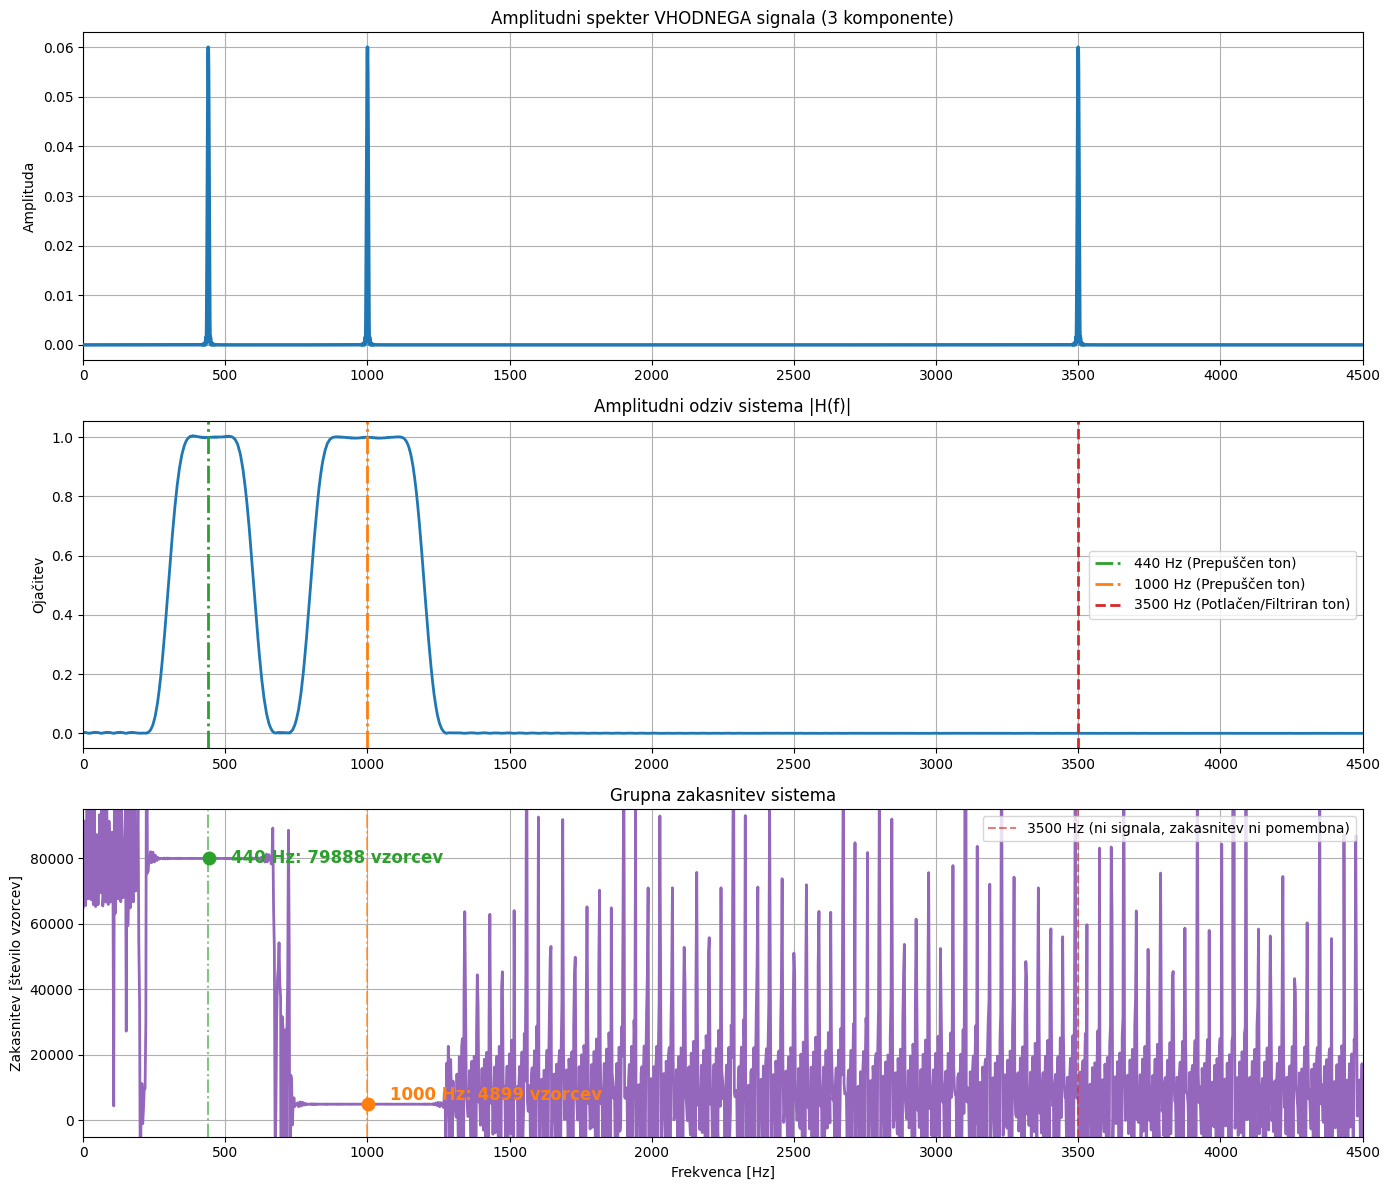

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# 1. Spekter vhodnega signala
N_fft = len(x_input)
xf_input = fftfreq(N_fft, 1/fs)
yf_input = fft(x_input)
magnitude_input = 2.0/N_fft * np.abs(yf_input[:N_fft//2])
freqs_input = xf_input[:N_fft//2]

# 2. Amplitudni odziv in grupna zakasnitev sistema
w, h_resp = signal.freqz(h, worN=8000, fs=fs)
w_gd, gd_samples = signal.group_delay((h, 1), w=8000, fs=fs)

# Določitev specifičnih vrednosti zakasnitve za naše frekvence
idx_440 = np.argmin(np.abs(w_gd - 440))
idx_1000 = np.argmin(np.abs(w_gd - 1000))
idx_3500 = np.argmin(np.abs(w_gd - 3500))

# Natančno število vzorcev zakasnitve
gd_samp_440 = int(gd_samples[idx_440])
gd_samp_1000 = int(gd_samples[idx_1000])

plt.figure(figsize=(14, 12))

# --- GRAF A: Amplitudni spekter vhodnega signala ---
plt.subplot(3, 1, 1)
# Uporabimo tab:blue, ki se lepo vidi tudi na temnih ozadjih
plt.plot(freqs_input, magnitude_input, color='tab:blue', linewidth=2.5, zorder=3)
plt.fill_between(freqs_input, magnitude_input, color='tab:blue', alpha=0.3, zorder=2)
plt.title('Amplitudni spekter VHODNEGA signala (3 komponente)')
plt.ylabel('Amplituda')
plt.xlim(0, 4500)
plt.grid(True, zorder=1)

# --- GRAF B: Amplitudni odziv sistema |H(f)| ---
plt.subplot(3, 1, 2)
plt.plot(w, np.abs(h_resp), linewidth=2, color='tab:blue')
# Dodamo črte za vse tri komponente z različnimi barvami
plt.axvline(440, color='tab:green', linestyle='-.', linewidth=2, label='440 Hz (Prepuščen ton)')
plt.axvline(1000, color='tab:orange', linestyle='-.', linewidth=2, label='1000 Hz (Prepuščen ton)')
plt.axvline(3500, color='tab:red', linestyle='--', linewidth=2, label='3500 Hz (Potlačen/Filtriran ton)')
plt.title('Amplitudni odziv sistema |H(f)|')
plt.ylabel('Ojačitev')
plt.xlim(0, 4500)
plt.legend(loc='center right')
plt.grid(True)

# --- GRAF C: Grupna zakasnitev sistema ---
plt.subplot(3, 1, 3)
plt.plot(w_gd, gd_samples, color='tab:purple', linewidth=2)

# KLJUČNO: Omejimo Y-os, da skrijemo matematične neskončnosti (1e6) pri filtriranih frekvencah!
plt.ylim(-5000, gd_samp_440 + 15000)

# Označimo zakasnitve s črtami
plt.axvline(440, color='tab:green', linestyle='-.', alpha=0.6)
plt.axvline(1000, color='tab:orange', linestyle='-.', alpha=0.6)
plt.axvline(3500, color='tab:red', linestyle='--', alpha=0.6, label='3500 Hz (ni signala, zakasnitev ni pomembna)')

# Dodamo pike na krivuljo
plt.plot(w_gd[idx_440], gd_samp_440, marker='o', markersize=9, color='tab:green')
plt.plot(w_gd[idx_1000], gd_samp_1000, marker='o', markersize=9, color='tab:orange')

# Dodamo TEKST in VREDNOSTI neposredno na graf poleg pik
plt.text(440 + 80, gd_samp_440, f'440 Hz: {gd_samp_440} vzorcev',
         color='tab:green', fontsize=12, fontweight='bold', va='center')
plt.text(1000 + 80, gd_samp_1000, f'1000 Hz: {gd_samp_1000} vzorcev',
         color='tab:orange', fontsize=12, fontweight='bold', va='bottom')

plt.title('Grupna zakasnitev sistema')
plt.xlabel('Frekvenca [Hz]')
plt.ylabel('Zakasnitev [število vzorcev]')
plt.xlim(0, 4500)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Razumevanje grupne zakasnitve (Interaktivna simulacija)

**Navodila za opazovanje:**
1. Opazujte zgornji graf (**Fazni odziv**). Ko povečujete parameter **Zakasnitev (n_delay)**, postaja premica faze strmejša.
2. **Grupna zakasnitev** ($\tau_g$) je matematično definirana kot negativni odvod faze ($\phi$) po frekvenci ($\omega$):
   $$\tau_g(\omega) = -\frac{d\phi(\omega)}{d\omega}$$
3. Ker je v tem idealiziranem primeru faza premica (linearna faza), je njen odvod konstanten. To pomeni, da se vse frekvence v našem signalu zamaknejo za točno isto število vzorcev in signal ohrani svojo obliko.
4. V spodnjem grafu opazite, kako se oranžni signal (izhod) odmika od modrega (vhod) premo sorazmerno s strmino faze. **Večja kot je strmina faze v frekvenčnem prostoru, večji je časovni zamik signala!**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import scipy.signal as signal

def vizualizacija_grupne_zakasnitve(f0=100.0, n_delay=50):
    fs = 1000  # Frekvenca vzorčenja
    t = np.arange(0, 500) / fs

    # 1. Ustvarimo vhodni signal: Gaussov sinusni paket (wave packet)
    # Ta oblika je boljša za vizualizacijo zakasnitve kot čisti sinus
    sigma = 0.02
    center = 0.1
    input_signal = np.exp(-0.5 * ((t - center) / sigma)**2) * np.sin(2 * np.pi * f0 * t)

    # 2. Simulacija zakasnitve (LČI sistem s konstantno grupno zakasnitvijo)
    # V frekvenčnem prostoru je to množenje z exp(-j * omega * n_delay)
    output_signal = np.roll(input_signal, int(n_delay))
    if n_delay > 0:
        output_signal[:int(n_delay)] = 0  # Počistimo artefakte roll-a

    # 3. Izračun faznega odziva sistema
    # Faza phi(omega) = -omega * n_delay
    freqs = np.linspace(0, fs/2, 500)
    omega = 2 * np.pi * freqs / fs
    phase_response = -omega * n_delay

    # RISANJE
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Zgornji graf: Frekvenčni prostor (Faza)
    ax1.plot(freqs, phase_response, color='tab:red', linewidth=2)
    ax1.set_title(f'Frekvenčni prostor: Fazni odziv (Strmina = Grupna zakasnitev {n_delay} vzorcev)')
    ax1.set_ylabel('Faza [radiani]')
    #ax1.ylim(0, -1600)
    ax1.grid(True)

    # Spodnji graf: Časovna domena (Zakasnitev)
    ax2.plot(t, input_signal, label='Vhodni paket', alpha=0.5, color='tab:blue')
    ax2.plot(t, output_signal, label='Izhodni paket (Zakasnjen)', linewidth=2, color='tab:orange')
    ax2.set_title('Časovna domena: Vpliv faznega odziva na položaj signala')
    ax2.set_xlabel('Čas [s]')
    ax2.set_ylabel('Amplituda')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Ustvarimo interaktivne kontrolnike
interact(vizualizacija_grupne_zakasnitve,
         f0=FloatSlider(min=50, max=200, step=10, value=100, description='Frekvenca [Hz]'),
         n_delay=FloatSlider(min=0, max=200, step=5, value=50, description='Zakasnitev [vzorci]'));

interactive(children=(FloatSlider(value=100.0, description='Frekvenca [Hz]', max=200.0, min=50.0, step=10.0), …